In [ ]:
!pip install --extra-index-url https://pypi.fury.io/theresearchsoftwarecompany/ dplus-api


Looking in indexes: https://pypi.org/simple, https://pypi.fury.io/theresearchsoftwarecompany/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 MB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 1.5 MB/s eta 0:00:00


In [ ]:
!pip install ase

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.4 MB/s eta 0:00:00


In [ ]:
from ase.cluster import Decahedron
# Mount google drive
from google.colab import drive
drive.mount('/content/drive')

def make_pdbfile(p,q,r)
  #pdbfile='/content/drive/MyDrive/pentarod.pdb'
  atom_type="Au"
  latt_par=4.08
  deca=Decahedron(atom_type,p,q,r,latt_par)
  xyz=deca.get_positions()
  nb_atoms=np.shape(xyz)[0]
  print("number of atoms in the structure: %d"%nb_atoms)
  x=xyz[:,0];y=xyz[:,1];z=xyz[:,2]

  #2 Write pdb file
  # limit of 9 999 atoms /segments since only 4 digits available
  number_segments=1+nb_atoms//10000
  print("number of segments in the structure: %d"%number_segments) # not used in code, only for info
  pdbfile='/content/drive/MyDrive/Dplus/pentarod_%s'%str(atom_type)+'_%d'%p+'_%d'%q+'_%d'%r+'.pdb'
  # write pdbfile
  pdb_template = "ATOM  {num:5} {atom:2}        {molnum:4}    {x:8.3f}{y:8.3f}{z:8.3f}{occ:6.2f}{temp_factor:6.2f}\n"
  pdb_lines = []
  molnum = 1
  occ=1
  temp_factor=0
  num = 1
  H_label = "1"
  for row_index in range(len(x)):
          atomlabel = atom_type

          pdb_lines.append(pdb_template.format(
                             num=num, atom=atomlabel,molnum=molnum, x=x[row_index], y=y[row_index], z=z[row_index],occ=occ,temp_factor=temp_factor))

          num += 1
          if num==10000:
                  molnum+=1
                  num=1

  with open(pdbfile, "w") as f:
          f.writelines(pdb_lines)
  print("pdb file created:", pdbfile)
  return pdfbfile




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
number of atoms in the structure: 22572001
number of segments in the structure: 2258
pdb file created: /content/drive/MyDrive/pentarod_Au_110_717_0.pdb


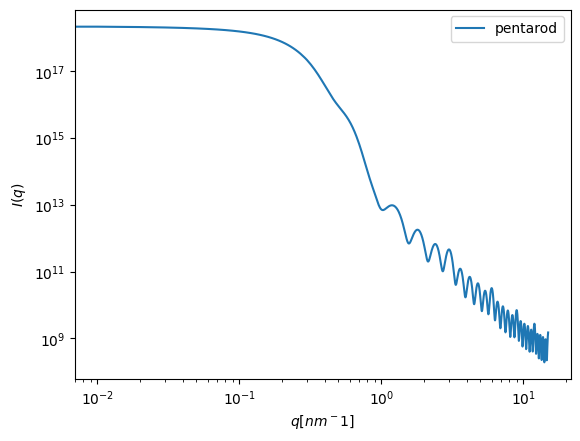

In [ ]:
from dplus.CalculationInput import CalculationInput # To create states
from dplus.CalculationRunner import EmbeddedLocalRunner # To access the backend and run the calculation
from dplus.DataModels.models import PDB
from dplus.DataModels import ManualSymmetry
#import dplus.g_r as g
import numpy as np
atom_type="Au"
p=110
q=717
r=0
pdbfile='/content/drive/MyDrive/Dplus/pentarod_%s'%str(atom_type)+'_%d'%p+'_%d'%q+'_%d'%r+'.pdb'

runner=EmbeddedLocalRunner()

q_max = 15
grid_size = 100
nbpoints=1500


## Create a PDB
Test_PDB = PDB(pdbfile)
Test_PDB.centered = True # Make sure the PDB is centered
Test_PDB.extra_params.solvent_method.value = 0

## Create a calculation state for only the PDB
state_PDB = CalculationInput()
state_PDB.Domain.populations[0].add_model(Test_PDB)
state_PDB.DomainPreferences.grid_size = 100
state_PDB.DomainPreferences.q_max = 15
state_PDB.DomainPreferences.generated_points = 1500
#apply instrumental resiloution
state_PDB.DomainPreferences.apply_resolution = True
state_PDB.DomainPreferences.resolution_sigma = 0.1
state_PDB.use_gpu = True

# run calculation
output_PDB = runner.generate(state_PDB)

import matplotlib.pyplot as plt

q = list(output_PDB.graph.keys())
I_q = list(output_PDB.graph.values())

output='/content/drive/MyDrive/Dplus/pentarod_%s'%str(atom_type)+'_%d'%p+'_%d'%q+'_%d'%r+'.iq'
np.savetxt(output,[q,I_q],delimiter='\t')

plt.loglog(0.1*q, I_q,label='pentarod')
plt.xlabel('$q [A^-1]$')
plt.ylabel('$I(q)$')
plt.legend()
plt.show()
